In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc

In [40]:
bentheimer_target = xr.open_dataset(r"DRP-421_archive\DRP-421\Bentheimer Sandstone\Bentheimer_Segmentation\BHG1eff_tst_phase.nc")
bentheimer_input = xr.open_dataset(r"DRP-421_archive\DRP-421\Bentheimer Sandstone\Bentheimer_Tomogram\block00000000.nc")
targets = bentheimer_target['phase'].to_numpy()
inputs = bentheimer_input['tomo'].to_numpy()

In [44]:
bentheimer_target

<xarray.Dataset> Size: 2GB
Dimensions:  (phase_zdim: 800, phase_ydim: 800, phase_xdim: 800)
Dimensions without coordinates: phase_zdim, phase_ydim, phase_xdim
Data variables:
    phase    (phase_zdim, phase_ydim, phase_xdim) float32 2GB 3.0 3.0 ... 3.0
Attributes:
    number_of_files:        1
    voxel_size_xyz:         [2.1592667 2.1592667 2.1592667]
    voxel_unit:             um
    zdim_range:             [  0 799]
    zdim_total:             800
    coordinate_origin_xyz:  [220 220 800]

In [45]:
bentheimer_input

<xarray.Dataset> Size: 513MB
Dimensions:         (md5sums_dim: 16, tomo_zdim: 400, tomo_ydim: 800,
                     tomo_xdim: 800, data_histogram_dim: 65531)
Dimensions without coordinates: md5sums_dim, tomo_zdim, tomo_ydim, tomo_xdim,
                                data_histogram_dim
Data variables:
    md5_checksum    (md5sums_dim) int8 16B ...
    tomo            (tomo_zdim, tomo_ydim, tomo_xdim) int16 512MB 13408 ... 1...
    data_histogram  (data_histogram_dim) float64 524kB ...
Attributes: (12/26)
    zdim_total:                                                         800
    number_of_files:                                                    2
    zdim_range:                                                         [  0 ...
    data_description:                                                   Raw r...
    voxel_size_xyz:                                                     [0.00...
    voxel_unit:                                                         mm
    ...                                                                 ...
    history_20201210_060528_tomo_R_SSw_SS_output:                       \n   ...
    history__projf32_LIN:                                               data_...
    history__projf32_LIN_output:                                        \ninp...
    data_min_max:                                                       [ 866...
    data_histogram_binsize:                                             1.0
    data_histogram_offset:                                              0.0

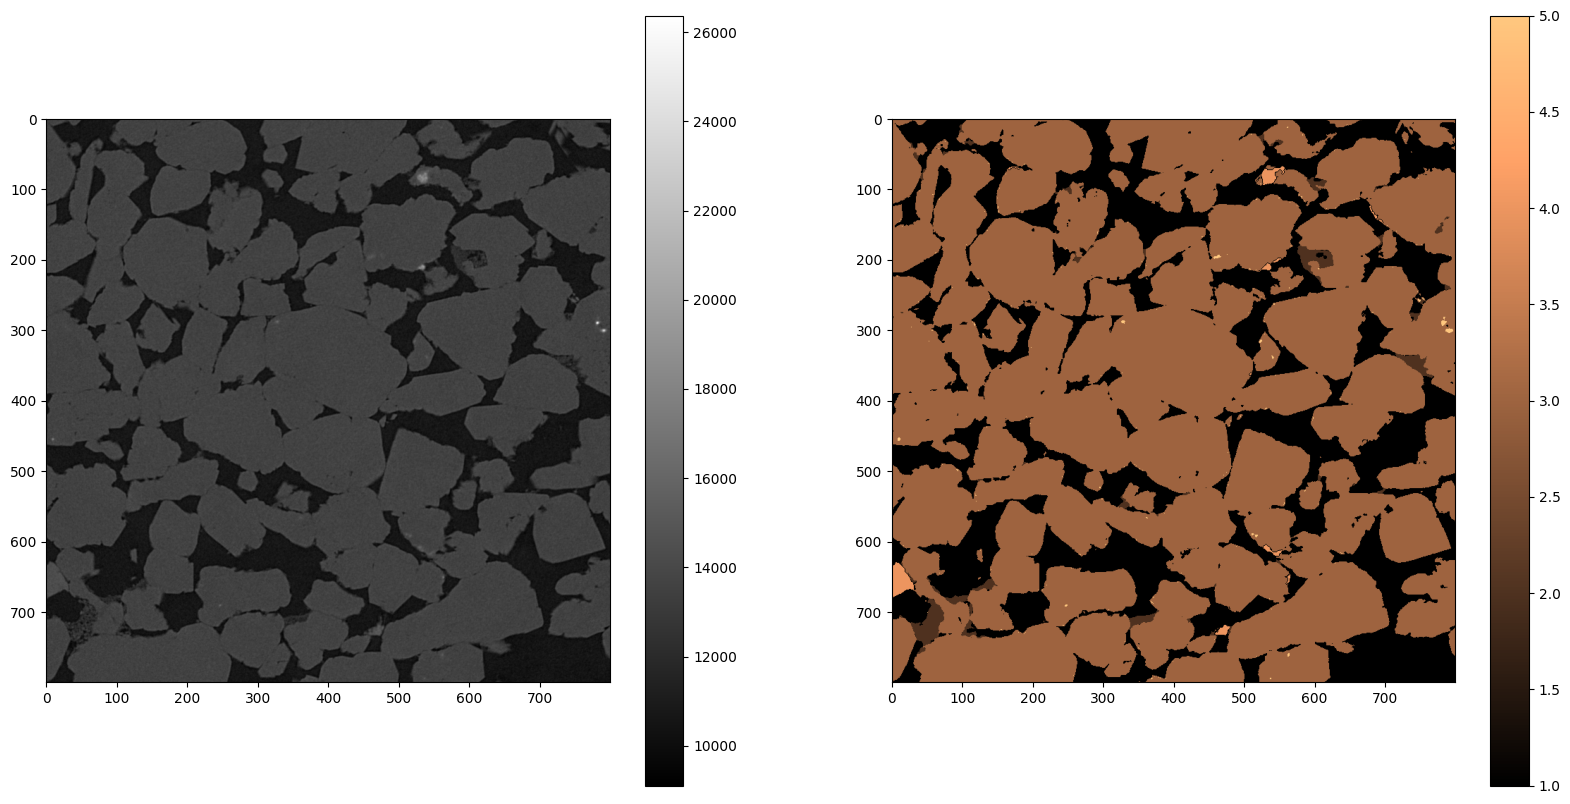

In [3]:
srez = inputs[0]
label = targets[0]
plt.figure(figsize=(20,10))
plt.subplot(121)
im = plt.imshow(srez, cmap = "gray")
plt.colorbar(im) 
plt.subplot(122)
im = plt.imshow(label, cmap = 'copper')
plt.colorbar(im) 

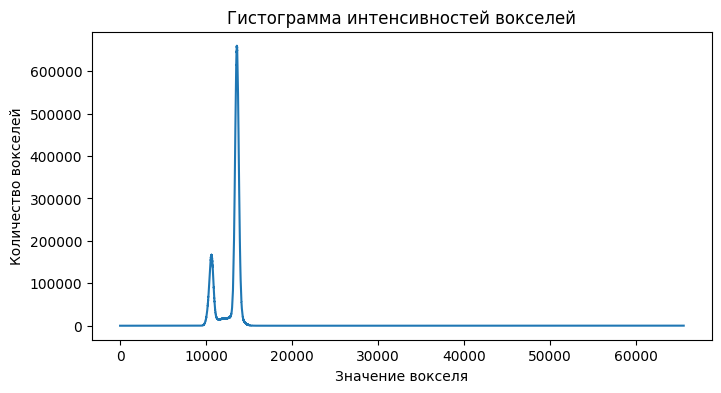

In [ ]:
hist = bentheimer_input['data_histogram'].values

plt.figure(figsize=(8,4))
plt.plot(hist)
plt.title("Гистограмма интенсивностей вокселей")
plt.xlabel("Значение вокселя")
plt.ylabel("Количество вокселей")
plt.show()

In [5]:
label_distribution = np.unique(targets, return_counts=True)
class_name_dict = ['поры', 'глина', 'кварц', '???', '???']

df = pd.DataFrame({
    'Класс': label_distribution[0],
    'Доля (%)': [100 * label_distribution[1][int(lab - 1)] / label_distribution[1].sum() for lab in label_distribution[0]],
    'Название': [class_name_dict[int(lab - 1)] for lab in label_distribution[0]]
})

df['Доля (%)'] = df['Доля (%)'].map(lambda x: f"{x:05.2f}")

print(df)

   Класс Доля (%) Название
0    1.0    25.38     поры
1    2.0    01.42    глина
2    3.0    72.12    кварц
3    4.0    00.99      ???
4    5.0    00.09      ???


In [6]:
pore_values = inputs[(targets == 1)[:400, :, :]]
rock_values = inputs[((targets == 2) | (targets == 3))[:400, :, :]]

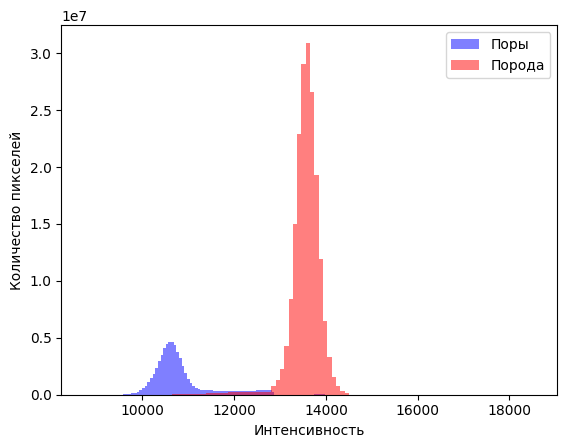

In [7]:
plt.hist(pore_values, bins=100, alpha=0.5, label='Поры', color='blue')
plt.hist(rock_values, bins=100, alpha=0.5, label='Порода', color='red')
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.legend()
plt.show()

In [47]:
castlegate_target = xr.open_dataset(r"DRP-421_archive\DRP-421\Castlegate Sandstone\Castlegate_Segmentation\CG_seg_800.nc")
castlegate_input = xr.open_dataset(r"DRP-421_archive\DRP-421\Castlegate Sandstone\Castlegate_Tomogram\block00000000.nc")
targets = castlegate_target['phase'].to_numpy()
inputs = castlegate_input['tomo'].to_numpy()

C:\Users\Пк\AppData\Local\Temp\ipykernel_20476\572532146.py:7: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1000 with 4 Axes> than <Figure size 2000x1000 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(im)


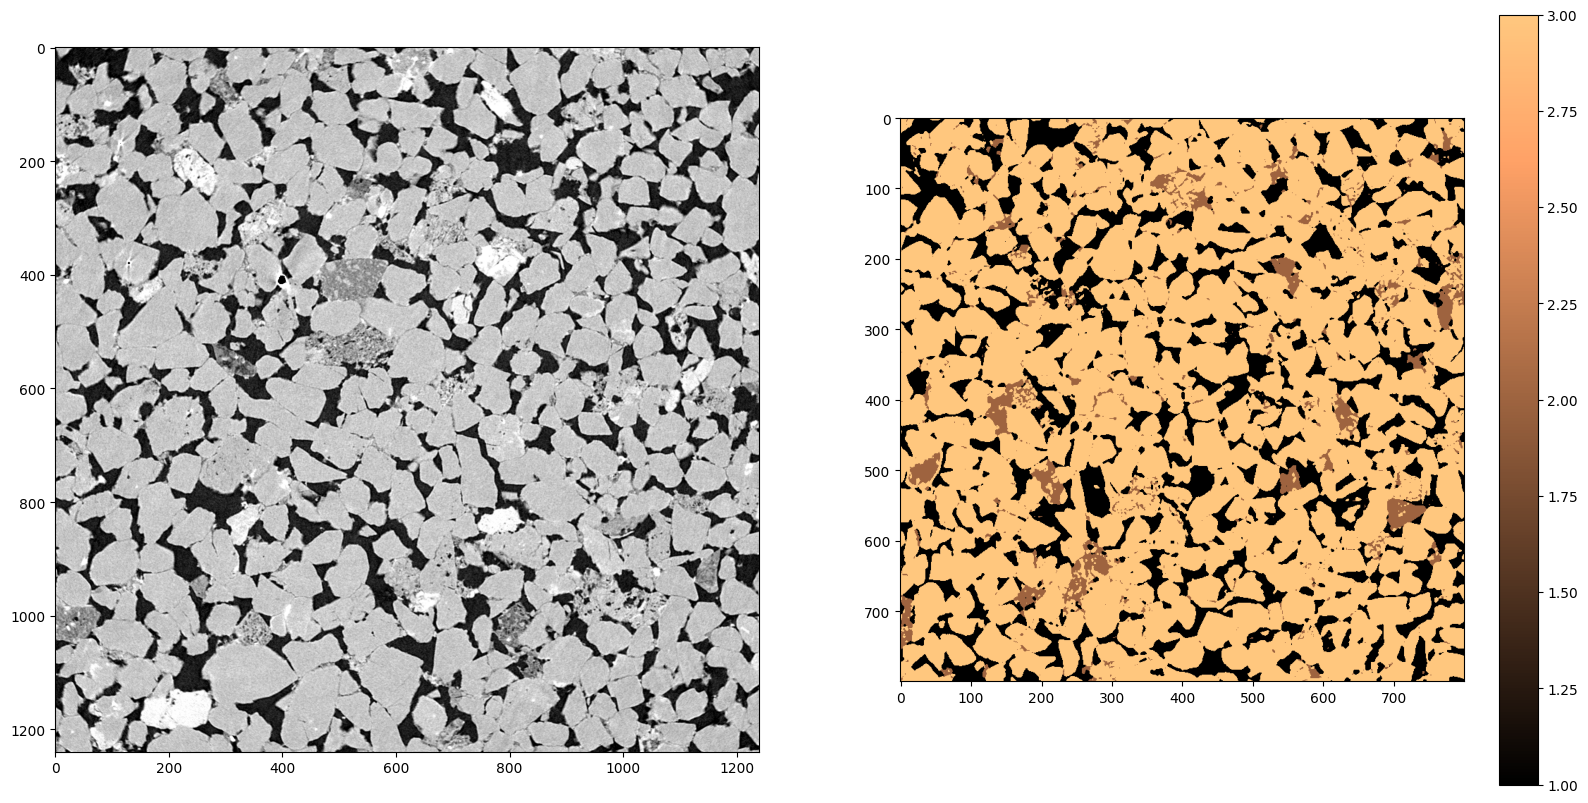

In [57]:
srez = inputs[0]
label = targets[0]
plt.figure(figsize=(20,10))
plt.subplot(121)
vmin, vmax = np.percentile(srez, [1, 99]) 
plt.imshow(srez, cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(im) 
plt.subplot(122)
im = plt.imshow(label, cmap = 'copper')
plt.colorbar(im) 

In [37]:
castlegate_input

<xarray.Dataset> Size: 512MB
Dimensions:         (md5sums_dim: 16, tomo_zdim: 400, tomo_ydim: 800,
                     tomo_xdim: 800, data_histogram_dim: 42463)
Dimensions without coordinates: md5sums_dim, tomo_zdim, tomo_ydim, tomo_xdim,
                                data_histogram_dim
Data variables:
    md5_checksum    (md5sums_dim) int8 16B ...
    tomo            (tomo_zdim, tomo_ydim, tomo_xdim) int16 512MB 11469 ... 1...
    data_histogram  (data_histogram_dim) float64 340kB ...
Attributes: (12/22)
    zdim_total:                                   800
    number_of_files:                              2
    zdim_range:                                   [  0 399]
    data_description:                             Raw reconstructed tomogram ...
    voxel_size_xyz:                               [0.00215103 0.00215103 0.00...
    voxel_unit:                                   mm
    ...                                           ...
    history_20141021_113947_tomo_R_SH_output:     \ninput dataset ID: 2014102...
    history_20211208_094306_tomoHiRes_SS:         base                    ss\...
    history_20211208_094306_tomoHiRes_SS_output:  \n   mango git repo: <https...
    data_min_max:                                 [ 7986. 42462.]
    data_histogram_binsize:                       1.0
    data_histogram_offset:                        0.0

In [32]:
castlegate_target

<xarray.Dataset> Size: 2GB
Dimensions:  (phase_zdim: 800, phase_ydim: 800, phase_xdim: 800)
Dimensions without coordinates: phase_zdim, phase_ydim, phase_xdim
Data variables:
    phase    (phase_zdim, phase_ydim, phase_xdim) float32 2GB 3.0 3.0 ... 3.0
Attributes:
    number_of_files:        1
    voxel_size_xyz:         [3.362701 3.362701 3.362701]
    voxel_unit:             um
    zdim_range:             [  0 799]
    zdim_total:             800
    coordinate_origin_xyz:  [ 410  410 1760]